# Week 2 : Day 2 Structured Outputs with Pydantic Fundamentals

### Written by: Hafiza Mehak Arif

### Date: 16-June-2026


# Task 3: Multi Entry Extraction


In [3]:
from pydantic import BaseModel
from typing import List

from langchain_groq import ChatGroq
from dotenv import load_dotenv

import os
import json

import networkx as nx
import matplotlib.pyplot as plt
print("Import Successfull")

Import Successfull


Define Nested Models


In [4]:
class Employee(BaseModel):
    name: str
    title: str
    department: str
    skills: List[str]

class Company(BaseModel):
    name: str
    location: str
    employees: List[Employee]

In [5]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

structured_llm = llm.with_structured_output(Company)

Sample Company Description


In [6]:
company_text = """
TechNova Solutions, headquartered in London, announced the expansion of its AI division.

Sarah Ahmed works as a Senior Data Scientist in the Research Department.
Her skills include Python, TensorFlow, and NLP.

James Wilson joined as a Machine Learning Engineer in the Engineering Department.
His expertise includes PyTorch, MLOps, and Computer Vision.
"""

Extracting Structure


In [9]:
company = structured_llm.invoke(
    f"""
    You are an information extraction assistant.

    Extract the following information from the text.

    Rules:
    - Use only explicitly stated information.
    - Do not guess missing information.
    - If information is missing, return "Not specified".
    - Extract all employees mentioned.

    Company Information:
    - Company Name
    - Location
    - Employees

    For each employee extract:
    - Name
    - Title
    - Department
    - Skills

    Text:
    {company_text}
    """
)
company

print(
    json.dumps(
        company.model_dump(),
        indent=4
    )
)

{
    "name": "TechNova Solutions",
    "location": "London",
    "employees": [
        {
            "name": "Sarah Ahmed",
            "title": "Senior Data Scientist",
            "department": "Research Department",
            "skills": [
                "Python",
                "TensorFlow",
                "NLP"
            ]
        },
        {
            "name": "James Wilson",
            "title": "Machine Learning Engineer",
            "department": "Engineering Department",
            "skills": [
                "PyTorch",
                "MLOps",
                "Computer Vision"
            ]
        }
    ]
}


Build the Knowledge Graph


In [10]:
G = nx.Graph()

# Add company node
G.add_node(company.name, node_type="Company")

for employee in company.employees:

    # Company → Employee
    G.add_node(employee.name, node_type="Employee")
    G.add_edge(company.name, employee.name)

    # Employee → Department
    G.add_node(employee.department, node_type="Department")
    G.add_edge(employee.name, employee.department)

    # Employee → Skills
    for skill in employee.skills:
        G.add_node(skill, node_type="Skill")
        G.add_edge(employee.name, skill)

Visualizing the Graph


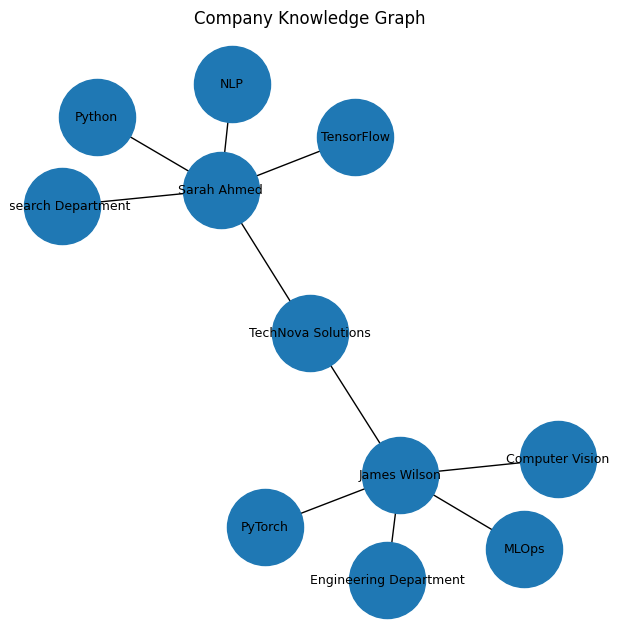

In [12]:
plt.figure(figsize=(6, 6))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=9
)

plt.title("Company Knowledge Graph")

plt.show()